In [1]:
# use extension to auto reload modules
%load_ext autoreload
%autoreload 2
# %load_ext line_profiler

In [2]:
import logging
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from simple_scraper import EcoCounterScraper
import meteostat

# Introduction

In this personal project, I'm interested in analyzing the bike counts measured by eco-counters systems with a few questions in mind. 
For examples, some questions of interest are : 
* What factors have an influence of the number of people passing on a counter on a certain day, and what are their relative importance ?
  In particular, factors of interest are : 
     - weather,
     - day of the week,
     - vacations,
     - time in the year,
     - etc.
* How can we compare the frequentations at a counter between two time periods, acounting for the effects of the variables above ?

A typical usecase for this kind of analysis is the attempt to quantify the variation of frequentation on a cyclepath after an event (improvement, etc.), correcting for the effects of exogeneous variables.
Other questions of interest could be "Are cyclists in Nice more sensitive to the rain than cyclists in Paris ?".

Well, before having fun with the data, the first step is to get them !

# Retrieving bike counts

In a perfect world, all these data - bought with our local taxes - would be available for free using a simple API. That will likely come one day !

Bur for now, they can just be viewed on a [web page](https://eco-display-map.eco-counter.com/site/300019544) from eco-counter.
Accordingly, I designed a simple scrapper which job is to fetch data from this page in order to retrieve :
- the daily bike counts
- the site name
- the site location

This scrapper uses the site id (found in the url when browsing the site) of the site from which data should be fetched.

## Build scrappers for the sites of interest

Below, a scrapper is built for each counter of interest. 
The counter ids are found from the information in the page/url of the sites of interest in the eco-counter site.

In [3]:
log = logging.getLogger('EcoCounterScraper')
log.setLevel(logging.DEBUG)
if not log.hasHandlers():
    ch = logging.StreamHandler()
    ch.setLevel(logging.DEBUG)
    formatter = logging.Formatter('%(asctime)s - %(name)s - %(levelname)s - %(message)s')
    ch.setFormatter(formatter)
    log.addHandler(ch)

In [4]:
cagnes_scrapper = EcoCounterScraper(site_id="300037212", nickname="Cagnes-sur-Mer")
paris_sebastopol_scrapper = EcoCounterScraper(site_id="100158705", nickname="Paris Sebastopol")
nice_carras_scrapper = EcoCounterScraper(site_id="300019544", nickname="Nice Carras")

scrappers = {scrapper.site_id : scrapper for scrapper in [cagnes_scrapper, paris_sebastopol_scrapper, nice_carras_scrapper]}

## Checking basic scrapper features

Right after initialization, the scrapper object does not hold more data besides the site id which was given at init.

In [5]:
example_scrapper = scrappers["300037212"]

The latest count can first be feched in order to check the scrapper and retrieve basic meta-data about the counter:

In [6]:
example_scrapper.fetch_counts()

2026-02-10 08:29:34,129 - EcoCounterScraper.site_300037212 - DEBUG - Fetching data from: https://eco-display-map.eco-counter.com/site/300037212?granularity=P1D&startDate=2026-02-09&endDate=2026-02-10
2026-02-10 08:29:35,832 - EcoCounterScraper.site_300037212 - DEBUG - Downloaded 632503 bytes
2026-02-10 08:29:35,835 - EcoCounterScraper.site_300037212 - DEBUG - Extracting data...
2026-02-10 08:29:35,836 - EcoCounterScraper.site_300037212 - DEBUG - Parsing HTML to extract embedded count data...
2026-02-10 08:29:35,868 - EcoCounterScraper.site_300037212 - DEBUG - Transforming global counts to DataFrame.
2026-02-10 08:29:35,880 - EcoCounterScraper.site_300037212 - DEBUG - Transforming directional counts to DataFrame.


,count,in,out
timestamp,,,
2026-02-09,2088,1023,1065


After a first call, the scrapper meta-data is initialized :

In [7]:
example_scrapper

EcoCounterScraper(site_id=300037212)
  Site name: Cagnes sur Mer (FR)
  Location: {'lat': 43.657754, 'lon': 7.168889}
  First data date: 2019-01-01

Using this scrapper, the data can be fetched over the whole history of the counter. "Online" analysis and additional automation may come later, but current focus is on playing with the data.

**Disclaimer** : *As this scrapper is highly dependent on the website implementation and may need a bit of time to retrieve everything, the whole history is retrieved once for all and saved to local persistent to begin with. This is done for each counter of interest.*

Below, the whole data since the first one is retrieved for each site of interest.

In [8]:
all_data_bike = {site_id: bike_scrapper.fetch_all_counts() for site_id, bike_scrapper in scrappers.items()}

2026-02-10 08:29:36,043 - EcoCounterScraper.site_300037212 - DEBUG - Requested period longer than 1 year with daily frequency. Splitting requests...
2026-02-10 08:29:36,045 - EcoCounterScraper.site_300037212 - DEBUG - Fetch data from 2019-01-01 to 2019-12-31...
2026-02-10 08:29:36,049 - EcoCounterScraper.site_300037212 - DEBUG - Fetching data from: https://eco-display-map.eco-counter.com/site/300037212?granularity=P1D&startDate=2019-01-01&endDate=2019-12-31


2026-02-10 08:29:38,085 - EcoCounterScraper.site_300037212 - DEBUG - Downloaded 632124 bytes
2026-02-10 08:29:38,087 - EcoCounterScraper.site_300037212 - DEBUG - Extracting data...
2026-02-10 08:29:38,088 - EcoCounterScraper.site_300037212 - DEBUG - Parsing HTML to extract embedded count data...
2026-02-10 08:29:38,113 - EcoCounterScraper.site_300037212 - DEBUG - Transforming global counts to DataFrame.
2026-02-10 08:29:38,116 - EcoCounterScraper.site_300037212 - DEBUG - Transforming directional counts to DataFrame.
2026-02-10 08:29:38,126 - EcoCounterScraper.site_300037212 - DEBUG - Fetch data from 2020-01-01 to 2020-12-30...
2026-02-10 08:29:38,127 - EcoCounterScraper.site_300037212 - DEBUG - Fetching data from: https://eco-display-map.eco-counter.com/site/300037212?granularity=P1D&startDate=2020-01-01&endDate=2020-12-30
2026-02-10 08:29:40,150 - EcoCounterScraper.site_300037212 - DEBUG - Downloaded 632124 bytes
2026-02-10 08:29:40,153 - EcoCounterScraper.site_300037212 - DEBUG - Ext

# Retrieving weather data

In order to analyse the effect of the weather on the frequentation, wheather data matching the counter location is required at least for each sample in the bike-counts table. This data is retrieved using the `meteostat` library and the counter location fetched from the eco-counter web pages. 

In [9]:
data_counters = {}

for bike_scrapper, data_bike in zip(scrappers.values(), all_data_bike.values()):
    counter_location = meteostat.Point(**bike_scrapper.site_location_)
    start = data_bike.index[0]
    end = data_bike.index[-1]
    data_weather = meteostat.Daily(counter_location, start, end).fetch()
    data_counters[bike_scrapper.site_id] = pd.concat([data_weather, data_bike], axis=1)

Add a basic feature defining if the day is rainy or not. Can be used for modelling or just as a categorical variable to highlight rainy days in the plots.

In [10]:
for data_counter in data_counters.values():
    data_counter['is_rainy'] = data_counter['prcp'] > 1.

In [11]:
data_counters["300037212"].head()

,tavg,tmin,tmax,prcp,snow,wdir,wspd,wpgt,pres,tsun,count,in,out,is_rainy
2021-06-14,23.5,20.5,25.3,0.0,<NA>,<NA>,7.8,24.1,1016.8,<NA>,414,205,209,False
2021-06-15,24.6,21.4,26.6,0.0,<NA>,<NA>,5.6,29.6,1016.7,<NA>,2401,1216,1185,False
2021-06-16,24.7,22.6,26.8,0.0,<NA>,<NA>,7.9,24.1,1015.8,<NA>,2538,1287,1251,False
2021-06-17,25.1,21.7,27.5,0.0,<NA>,<NA>,14.0,31.0,1015.9,<NA>,2402,1200,1202,False
2021-06-18,24.4,21.8,26.2,0.0,<NA>,<NA>,16.2,42.0,1016.4,<NA>,2188,1111,1077,False


The structure of the weather data is explained in the Meteostat documentation: https://dev.meteostat.net/python/daily.html#data-structure : 
* temperatures are in °C
* precipitations in total mm over the day
* pressure (at sea level) in hPa
* wind speeds (average and peak gust) in km/h
* snow depth in mm (if non 0)
* total daily sunchine in min
* wind direction in ° (but dismissed as mostly/always NA)

# Add relevant calendar data

Besides weather data, it is quiet expected that other calendar-related features have a string influence on the daily bike counts. Typically, expected things which may have an influence are : 
- the day of week,
- holidays,
- vacations,
- weekend/weekdays,
- the date itself (month, week number etc.).

Of course, some of these variables are correlated. Defining which ones are the most relevant and should be integrated in the analysis will be one of the next steps of this work.

## The basics

First, add a few basic features like weekday, wether its is weekend or not, rainy or not.

In [12]:
for data_counter in data_counters.values():
    data_counter['is_weekend'] = data_counter.index.dayofweek >= 5
    data_counter['weekday'] = data_counter.index.day_name()

In [13]:
data_counters["300037212"].head()

,tavg,tmin,tmax,prcp,snow,wdir,wspd,wpgt,pres,tsun,count,in,out,is_rainy,is_weekend,weekday
2021-06-14,23.5,20.5,25.3,0.0,<NA>,<NA>,7.8,24.1,1016.8,<NA>,414,205,209,False,False,Monday
2021-06-15,24.6,21.4,26.6,0.0,<NA>,<NA>,5.6,29.6,1016.7,<NA>,2401,1216,1185,False,False,Tuesday
2021-06-16,24.7,22.6,26.8,0.0,<NA>,<NA>,7.9,24.1,1015.8,<NA>,2538,1287,1251,False,False,Wednesday
2021-06-17,25.1,21.7,27.5,0.0,<NA>,<NA>,14.0,31.0,1015.9,<NA>,2402,1200,1202,False,False,Thursday
2021-06-18,24.4,21.8,26.2,0.0,<NA>,<NA>,16.2,42.0,1016.4,<NA>,2188,1111,1077,False,False,Friday


## Specific french holidays

Most of the "non-worked" days besides weekends are specific to France or to the place in France where the counter is located (the vacation zone).
In order to flag these days a handy package is used : while it is not "solid" enought for a use in prod, we're just playing here so let's use it !

Now, add a boolean to tag the french holidays :

In [14]:
import jours_feries_france as jff

In [15]:
for data_counter in data_counters.values():
    data_counter['is_holiday'] = False
    for year in data_counter.index.year.unique():
        for holiday in jff.JoursFeries.for_year(year).values():
            holiday = pd.Timestamp(holiday)
            if holiday in data_counter.index:
                data_counter.loc[holiday, 'is_holiday'] = True

In [16]:
data_counters["300037212"].tail(20)

,tavg,tmin,tmax,prcp,snow,wdir,wspd,wpgt,pres,tsun,count,in,out,is_rainy,is_weekend,weekday,is_holiday
2026-01-21,8.7,5.7,13.0,0.0,<NA>,<NA>,16.0,34.0,1008.2,422.0,2323,1165,1158,False,False,Wednesday,False
2026-01-22,8.6,7.0,11.2,0.1,<NA>,<NA>,13.3,31.0,1000.1,7.0,1424,725,699,False,False,Thursday,False
2026-01-23,9.6,7.7,12.0,1.4,<NA>,<NA>,15.4,40.0,999.5,5.0,690,334,356,True,False,Friday,False
2026-01-24,9.1,6.9,12.0,7.6,<NA>,<NA>,17.2,51.0,999.2,36.0,828,414,414,True,True,Saturday,False
2026-01-25,8.7,6.0,12.0,3.4,<NA>,<NA>,14.8,40.8,998.2,237.0,1854,908,946,True,True,Sunday,False
2026-01-26,8.9,5.8,13.0,0.0,<NA>,<NA>,16.3,34.0,1000.4,483.0,2553,1271,1282,False,False,Monday,False
2026-01-27,7.6,5.5,11.0,31.0,<NA>,<NA>,21.8,53.0,1003.1,15.0,800,403,397,True,False,Tuesday,False
2026-01-28,9.1,7.0,11.2,30.7,<NA>,<NA>,15.8,57.0,990.3,43.0,403,214,189,True,False,Wednesday,False
2026-01-29,8.9,6.0,13.6,0.0,<NA>,<NA>,14.3,26.0,994.7,523.0,2495,1239,1256,False,False,Thursday,False
2026-01-30,9.2,6.0,14.0,0.0,<NA>,<NA>,14.1,32.0,999.5,203.0,1788,877,911,False,False,Friday,False


Same for the vacations, except that the local dates depend on the location of the counter. For now, just manage this manually :

In [17]:
zones_vacations = {
    "300037212": "B", # Cagnes-sur-Mer is in Alpes-Maritimes, zone B
    "100158705": "C", # Paris is in zone C
    "300019544": "B", # Nice is in Alpes-Maritimes, zone B
  }

In [18]:
import vacances_scolaires_france as vsf
school_holidays = vsf.SchoolHolidayDates()

In [19]:
for site_id, data_counter in data_counters.items():
    zone_vacations = zones_vacations[site_id]
    data_counter['is_vacations'] = False
    for year in data_counter.index.year.unique():
        for holiday in school_holidays.holidays_for_year_and_zone(year, zone_vacations).keys():
            holiday = pd.Timestamp(holiday)
            if holiday in data_counter.index:
                data_counter.loc[holiday, 'is_vacations'] = True

In [20]:
data_counters["300037212"].tail(20)

,tavg,tmin,tmax,prcp,snow,wdir,wspd,wpgt,pres,tsun,count,in,out,is_rainy,is_weekend,weekday,is_holiday,is_vacations
2026-01-21,8.7,5.7,13.0,0.0,<NA>,<NA>,16.0,34.0,1008.2,422.0,2323,1165,1158,False,False,Wednesday,False,False
2026-01-22,8.6,7.0,11.2,0.1,<NA>,<NA>,13.3,31.0,1000.1,7.0,1424,725,699,False,False,Thursday,False,False
2026-01-23,9.6,7.7,12.0,1.4,<NA>,<NA>,15.4,40.0,999.5,5.0,690,334,356,True,False,Friday,False,False
2026-01-24,9.1,6.9,12.0,7.6,<NA>,<NA>,17.2,51.0,999.2,36.0,828,414,414,True,True,Saturday,False,False
2026-01-25,8.7,6.0,12.0,3.4,<NA>,<NA>,14.8,40.8,998.2,237.0,1854,908,946,True,True,Sunday,False,False
2026-01-26,8.9,5.8,13.0,0.0,<NA>,<NA>,16.3,34.0,1000.4,483.0,2553,1271,1282,False,False,Monday,False,False
2026-01-27,7.6,5.5,11.0,31.0,<NA>,<NA>,21.8,53.0,1003.1,15.0,800,403,397,True,False,Tuesday,False,False
2026-01-28,9.1,7.0,11.2,30.7,<NA>,<NA>,15.8,57.0,990.3,43.0,403,214,189,True,False,Wednesday,False,False
2026-01-29,8.9,6.0,13.6,0.0,<NA>,<NA>,14.3,26.0,994.7,523.0,2495,1239,1256,False,False,Thursday,False,False
2026-01-30,9.2,6.0,14.0,0.0,<NA>,<NA>,14.1,32.0,999.5,203.0,1788,877,911,False,False,Friday,False,False


In [21]:
bike_scrapper.nickname.casefold().replace("-", "_").replace(" ", "_")

'nice_carras'

# Store the data

Now that the bike counts, weather and calendar data were retrieved for each counter, the history is simply dropped to a file for each site in order to be more easily used offline and in other studies.

As this work is just a very preliminary toycase, this structure seems best suited at the prototyping step.

In [ ]:
for scrapper, data_counter in zip(scrappers.values(), data_counters.values()):
    nickname_clean = scrapper.nickname.casefold().replace("-", "_").replace(" ", "_")
    data_counter.index.name = "date"
    data_counter.to_csv(f"data/{nickname_clean}_bike_counts_with_weather.csv", index=True)
    data_counter.to_parquet(f"data/{nickname_clean}_bike_counts_with_weather.parquet", index=True)

In [23]:
for scrapper, data_counter in zip(scrappers.values(), data_counters.values()):
    nickname_clean = scrapper.nickname.casefold().replace("-", "_").replace(" ", "_")
    latest_date = data_counter.index.max().strftime("%Y_%m_%d")
    data_counter.index.name = "date"
    data_counter.to_csv(
        f"data/{nickname_clean}_bike_counts_with_weather_{latest_date}.csv", index=True
    )
    data_counter.to_parquet(
        f"data/{nickname_clean}_bike_counts_with_weather_{latest_date}.parquet", index=True
    )

# A few plots just to see how they look

The data will be investigated more thouroughly in future notebooks. 
However, I cannot resist the desire to plot the data in a basic way in order to check the order of magnitudes and try to guess first patterns.

The cell below plots the bike counts VS temperature for each counter. 
The markers and colors are used to differentiate between weekends/weekays and rainy/non rainy days.

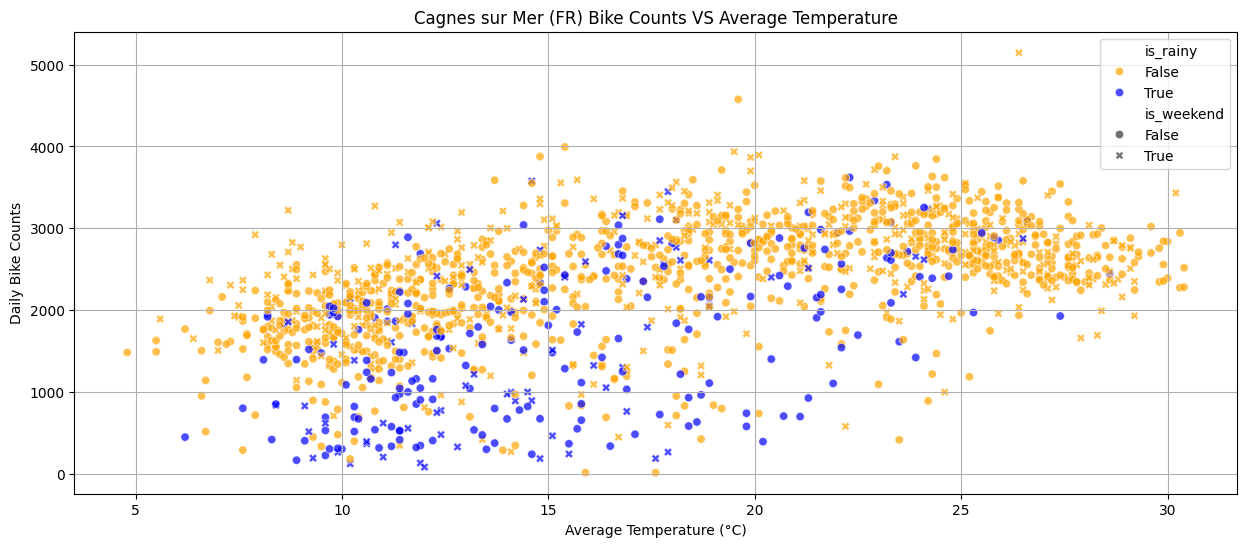

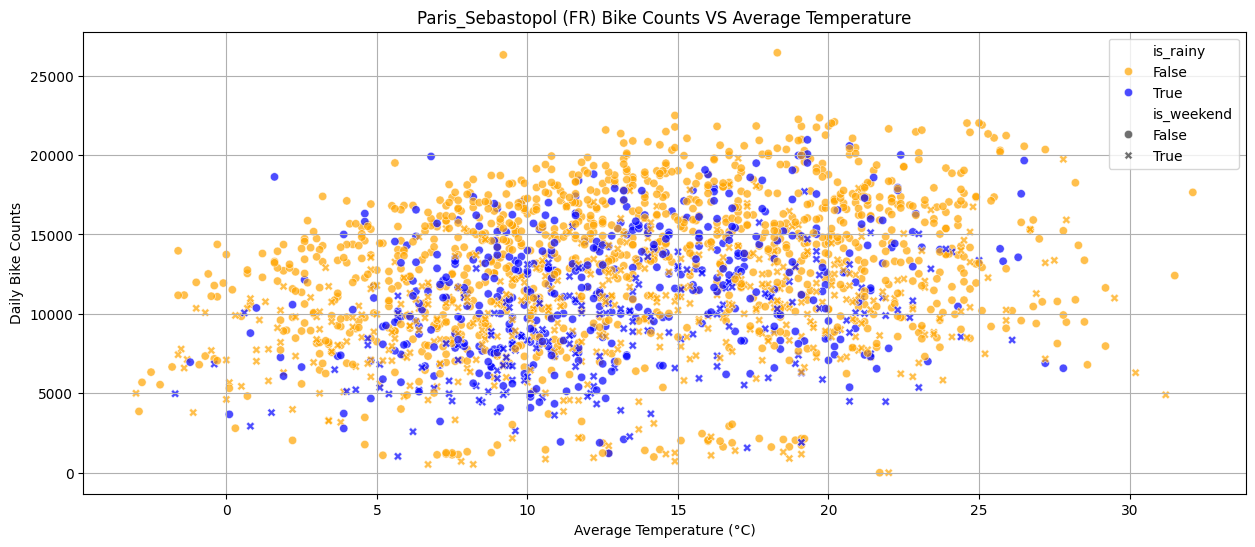

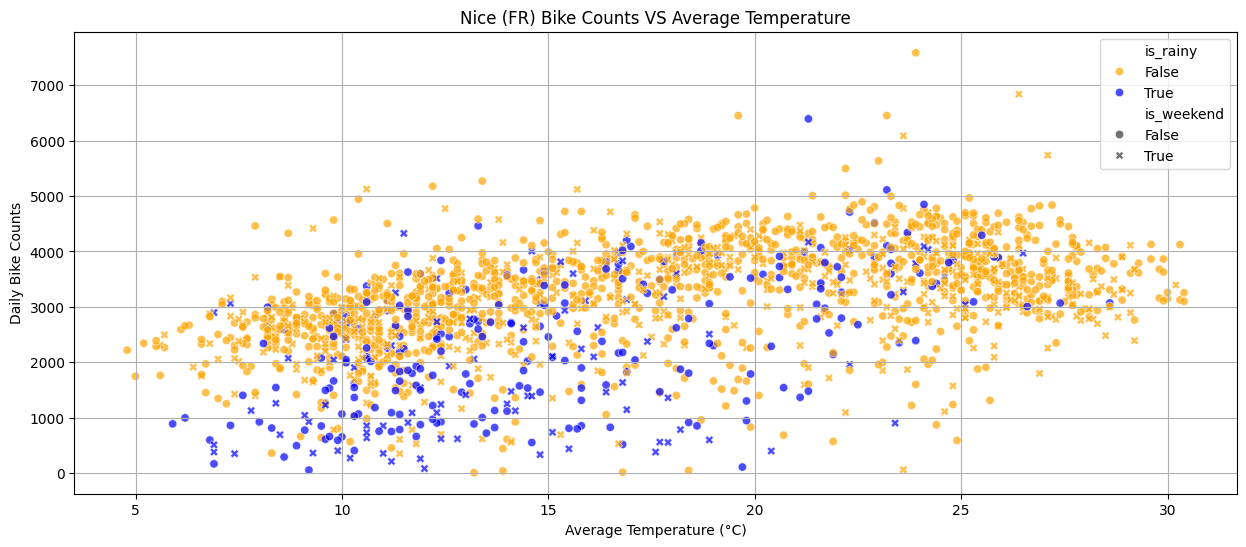

In [ ]:
for bike_scrapper, data_counter in zip(scrappers.values(), data_counters.values()):
    plt.figure(figsize=(15, 6))
    sns.scatterplot(
        data=data_counter.drop(columns=['snow', 'wdir', 'tsun']).dropna(),
        x='tavg',
        y='count',
        hue='is_rainy',
        palette={True: 'blue', False: 'orange'},
        alpha=0.7,
        style='is_weekend',
    )
    plt.title(f'{bike_scrapper.site_name_} Bike Counts VS Average Temperature')
    plt.xlabel('Average Temperature (°C)')
    plt.ylabel('Daily Bike Counts')
    plt.grid(which='both')


These simple graphs are not enough to fully understand the dynamics which govern the bike counts evolution, but a few important patterns can be noticed.

First, the average daily temperature seems to have an effect on the daily count of cyclists : roughly, the count seems to increase with temperature until 25°C, and then decrease as the temperature increases over 25°C.
It is possible that some of the observed variations result from calendar effects (correleted with the temperatures) but this is not distinguishable here and, overall, the observed pattern seems consistent with the cyclists habits : people tend to bike more easily in mild weather, while too cold or too hot temperature discourage the less enthusiastic cyclists.
Future work will be focused on quantifying these effects.

Secondly, rain seems to have an effect on the bike counts. What a surprise ! From the graphs, frequentation seems to be significantly reduced on rainy days, especially in Nice and Cagnes. 
Comparatively, the effect seems lower in Paris but this has to be confirmed.
As rain can be very intense in mediterrannean climate, and lighter in Paris, it would be interesting to study the effect of the amount of precipitation rather than the presence of rain as a boolean.

Finally, weekend/weekday effect seems (and this is really a guess) to be different across the sites:
- In Paris Sebastopol, the highest points in the graph for each temperature are always weekdays.
- In Cagnes-sur-Mer, weekends seem to be more represented, especially for colder days, while this is not true anymore for hot days.
- In Nice, the situation seems to be a bit more balanced.

These observations can be considered together with some local knowledge of the context of each counter : 
- The counter on Paris Sebastopol is located in a dense, urbanized, environnement, on a boulevard which is very used by commuters, which is consistent whith a dominance of weekdays for the top frequentation.
- The counter in Cagnes-sur-Mer is located along the sea, on a cyclepath which is at the same time used by commuters going to Nice or Sophia-Antipolis (long commutes), but is also very popular for families and sport cyclists for leisure rides. This is consistent with a higher frequentation on weekends off season, and all-week long in high season where tourists are more present.
- The counter in Nice Carras is in a bit more balanced situation. As for Cagnes, it is located on the sea-side, on the most important cycle-path for commuters going to the center of Nice or the main business area of the city. This place is also popular for sport-cyclist and tourists, while being located in a less "family-friendly" area.

While these a-posteriori interpretations should not be taken for granted, as the confirmation bias is never far aways, they are interesting as they illustrate that, depending on the location of the counter, the same variable might have a different effect.
Counter-specific models/analysis should accordingly be used to begin with.